## Credit Churn Prediction

### Business Problem: Credit Card Churn and Machine Learning Classification Application
Credit card churn is a constant concern for financial institutions, as customer loss can result in significant revenue loss and loss of market share. Faced with this challenge, companies seek to understand the factors that lead customers to close their credit cards and develop effective strategies to prevent churn.

A promising approach to addressing credit card churn is the application of machine learning classification techniques. These techniques allow predicting whether a customer is likely to cancel their credit card based on a variety of variables, such as transaction history, payment behavior, customer service interactions, and demographic information.

Applying machine learning classification in the context of credit card churn involves several steps. First, it is necessary to collect and prepare the relevant data for modeling, ensuring that it is clean, complete, and ready for analysis. This may involve integrating data from multiple sources, selecting relevant features, and encoding categorical variables.

The prepared data is then split into training and testing sets, and a classification algorithm such as logistic regression, decision trees, random forests, or neural networks is trained on the training data. During training, the algorithm learns patterns in the data that are associated with churn and adjusts its parameters to optimize the model’s performance.

After training, the model is evaluated using test data to check its ability to generalize to new data. This involves analyzing performance metrics such as precision, recall, F1-score, and area under the ROC curve to determine how well the model is able to predict churn.

Based on the model evaluation, the algorithm’s parameters can be adjusted and the model refined to improve its accuracy and generalization. Once a satisfactory model has been developed, it can be deployed into production and used to predict churn in real time, allowing companies to identify at-risk customers and implement proactive retention measures.

In summary, applying machine learning classification in the context of credit card churn offers a powerful and effective approach to preventing customer loss and maintaining long-term profitability. By accurately predicting churn, financial institutions can take proactive steps to retain customers, improve customer satisfaction, and drive long-term business growth.

In [30]:
# System Libraries
import re 
import os 
import unicodedata
import itertools


# Library for file manipulation
import pandas as pd 
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Data Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration for graphs width and layout of graphs
sns.set_theme(style = 'whitegrid')
palette = 'viridis'

# Warnings remove warnings
import warnings
warnings.filterwarnings("ignore")

# MLflow setup: local sqlite backend for tracking and artifacts in ./mlruns
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
MLFLOW_EXPERIMENT_NAME = "churn_prediction_experiment_without_smote"
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

def mlflow_log_model(model, name, artifact_path='model'):
    if 'XGB' in type(model).__name__:
        mlflow.xgboost.log_model(model, artifact_path=artifact_path)
    elif 'LGBM' in type(model).__name__:
        mlflow.lightgbm.log_model(model, artifact_path=artifact_path)
    else:
        mlflow.sklearn.log_model(model, artifact_path=artifact_path)

### Database

- **CLIENTNUM**: Unique identification number for each customer.
- **Attrition_Flag**: Indicates whether the customer has canceled the credit card (churn). It can have values such as `"Existing Customer"` or `"Attrited Customer"`.
- **Customer_Age**: Age of the customer.
- **Gender**: Gender of the customer.
- **Dependent_count**: Number of dependents of the customer.
- **Education_Level**: Level of education of the customer.
- **Marital_Status**: Marital status of the customer.
- **Income_Category**: Income category of the customer.
- **Card_Category**: Credit card category, such as `"Blue"`, `"Silver"`, `"Gold"`, or `"Platinum"`.
- **Months_on_book**: Number of months since the customer opened the account.
- **Total_Relationship_Count**: Total number of banking products held by the customer.
- **Months_Inactive_12_mon**: Number of months the customer was inactive during the last 12 months.
- **Contacts_Count_12_mon**: Number of contacts the customer had with the institution during the last 12 months.
- **Credit_Limit**: Customer's credit limit.
- **Total_Revolving_Bal**: Customer's total revolving credit balance.
- **Avg_Open_To_Buy**: Average amount available for purchases.
- **Total_Amt_Chng_Q4_Q1**: Percentage change in transaction amount from Q4 to Q1.
- **Total_Trans_Amt**: Total amount of transactions made by the customer.
- **Total_Trans_Ct**: Total number of transactions made by the customer.
- **Total_Ct_Chng_Q4_Q1**: Percentage change in the number of transactions from Q4 to Q1.
- **Avg_Utilization_Ratio**: Average credit utilization ratio.
- **Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1**: Value derived from a Naive Bayes model to predict churn. **Not used for analysis.**
- **Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2**: Another value derived from a Naive Bayes model to predict churn. **Not used for analysis.**

In [32]:
# Database

# Set Pandas options to display all columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

DATA_PATH = "../data/raw/BankChurners.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head(5)

Shape: (10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [33]:
df.tail()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,6,2,4,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189,0.996620,0.003377


In [34]:
df = df.drop(['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'], axis = 1)

In [35]:
df.shape

(10127, 21)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [37]:
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category'],
      dtype='object')


### Data Analysis 

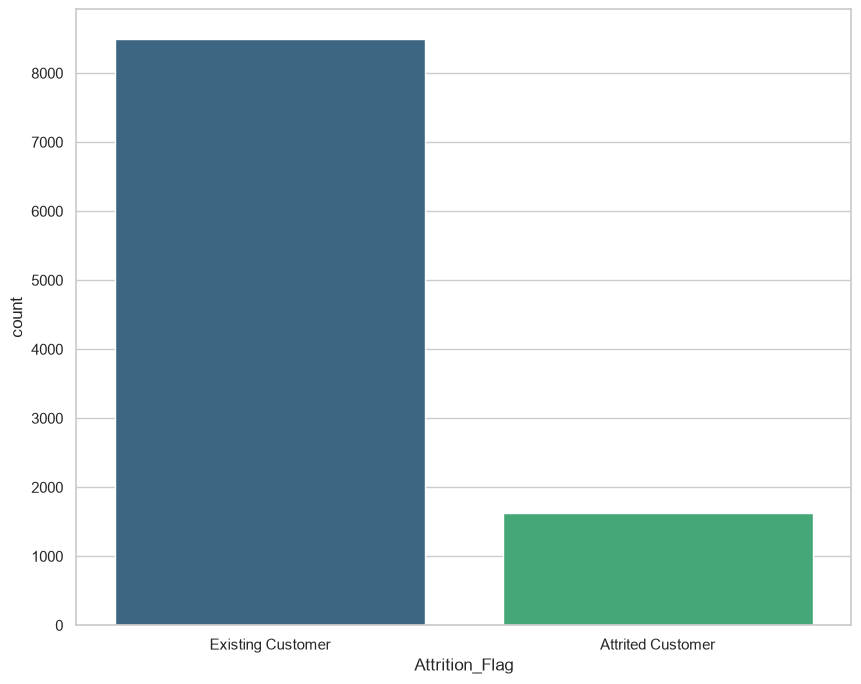

In [38]:
plt.figure(figsize = (10 , 8))
sns.countplot(data = df, x = 'Attrition_Flag', palette = palette)
plt.show()

- **Analysis**: Here, this variable represents the columns, such as churn and non-churn, which are essential attributes for training a machine learning model. The target column, in this context, refers to the variable that the model will try to predict or classify, such as churn, which is crucial for analyzing and predicting customer behavior.

In [39]:
df.corr(numeric_only = True)

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
CLIENTNUM,1.000000,0.007613,0.006772,0.134588,0.006907,0.005729,0.005694,0.005708,0.000825,0.005633,0.017369,-0.019692,-0.002961,0.007696,0.000266
Customer_Age,0.007613,1.000000,-0.122254,0.788912,-0.010931,0.054361,-0.018452,0.002476,0.014780,0.001151,-0.062042,-0.046446,-0.067097,-0.012143,0.007114
Dependent_count,0.006772,-0.122254,1.000000,-0.103062,-0.039076,-0.010768,-0.040505,0.068065,-0.002688,0.068291,-0.035439,0.025046,0.049912,0.011087,-0.037135
Months_on_book,0.134588,0.788912,-0.103062,1.000000,-0.009203,0.074164,-0.010774,0.007507,0.008623,0.006732,-0.048959,-0.038591,-0.049819,-0.014072,-0.007541
Total_Relationship_Count,0.006907,-0.010931,-0.039076,-0.009203,1.000000,-0.003675,0.055203,-0.071386,0.013726,-0.072601,0.050119,-0.347229,-0.241891,0.040831,0.067663
Months_Inactive_12_mon,0.005729,0.054361,-0.010768,0.074164,-0.003675,1.000000,0.029493,-0.020394,-0.042210,-0.016605,-0.032247,-0.036982,-0.042787,-0.038989,-0.007503
Contacts_Count_12_mon,0.005694,-0.018452,-0.040505,-0.010774,0.055203,0.029493,1.000000,0.020817,-0.053913,0.025646,-0.024445,-0.112774,-0.152213,-0.094997,-0.055471
Credit_Limit,0.005708,0.002476,0.068065,0.007507,-0.071386,-0.020394,0.020817,1.000000,0.042493,0.995981,0.012813,0.171730,0.075927,-0.002020,-0.482965
Total_Revolving_Bal,0.000825,0.014780,-0.002688,0.008623,0.013726,-0.042210,-0.053913,0.042493,1.000000,-0.047167,0.058174,0.064370,0.056060,0.089861,0.624022
Avg_Open_To_Buy,0.005633,0.001151,0.068291,0.006732,-0.072601,-0.016605,0.025646,0.995981,-0.047167,1.000000,0.007595,0.165923,0.070885,-0.010076,-0.538808


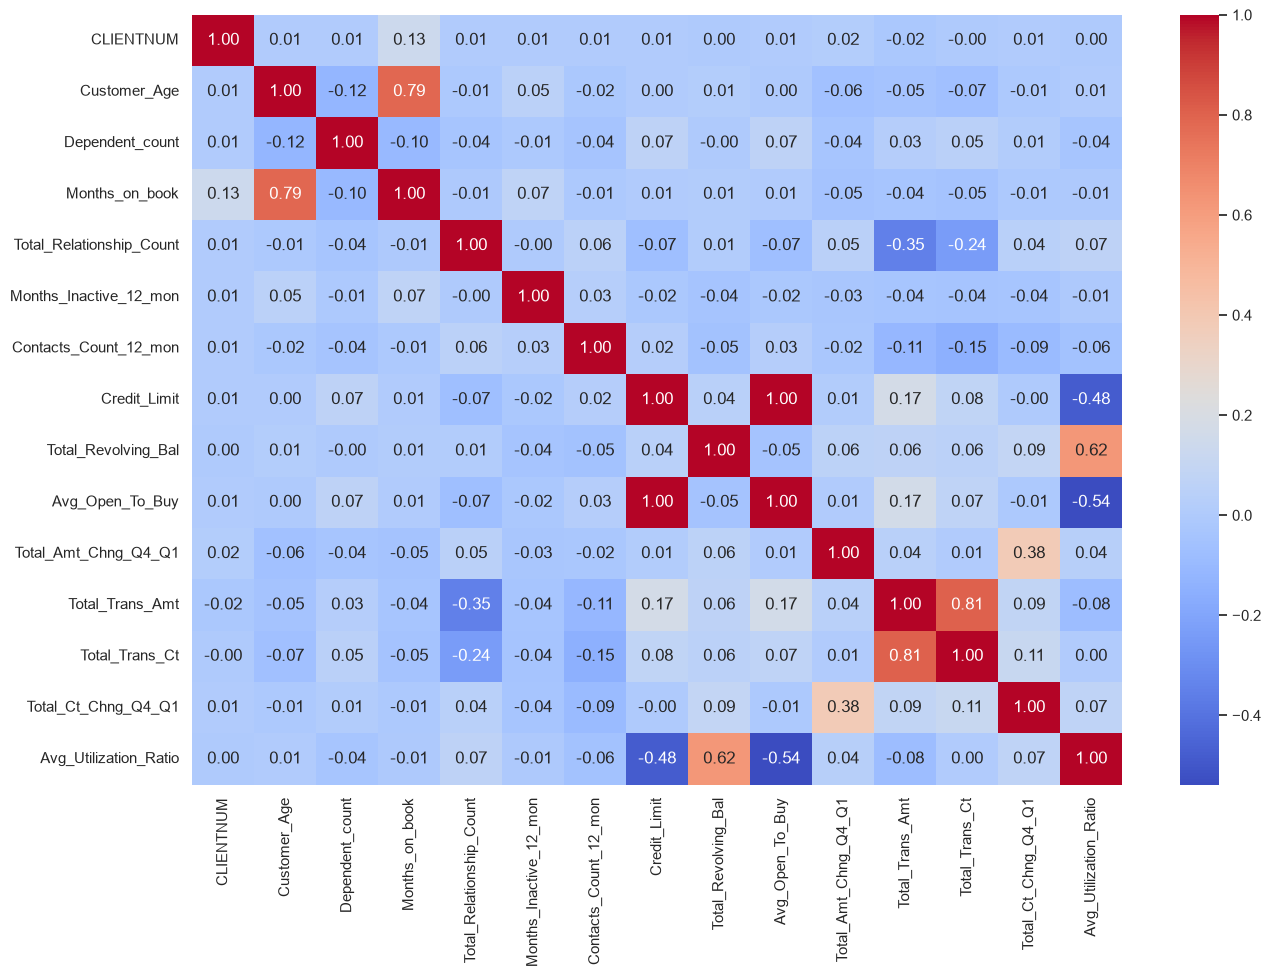

In [40]:
plt.figure(figsize = (15,10))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.show()

**Analysis**: Total transactions, total revolving balance, and total change in number are moderately negatively correlated with the target. This makes perfect sense. The fewer transactions a customer makes, the more likely they are to churn. Additionally, customers with lower revolving balances and less variation in their transaction numbers are likely to churn due to inactivity.

Customer age and months on the book are strongly positively correlated. The older a customer is, the more time they spend using the bank’s credit card services and vice versa. Thus, the company should focus its efforts on retaining old and loyal customers and increasing the retention of younger customers. Credit limit and average utilization rate are moderately negatively correlated. The higher the customer’s credit limit, the lower the average utilization rate. Total revolving balance and average utilization rate are strongly positively correlated. This makes sense.

As a customer uses their credit card more, they will have to pay higher revolving balances. Interestingly, gender has a moderate positive correlation with credit limit. This could indicate that male customers tend to have higher credit limits than female customers. Some characteristics that are naturally related are highly correlated, as expected. This is the case for total transaction value and total transactions.

When building linear models, we should be concerned about multicollinearity issues, which occur when two or more independent variables are highly correlated. Although it is diagnosed with the variance inflation factor, looking at the pairwise Pearson correlation can clue us in to this issue. This is the case here. However, since I will focus on predictive power, using more robust algorithms such as LightGBM, I will not worry about it now. Interestingly, the average open to purchase amount and credit limit are perfectly positively correlated.

This means that these two variables have a strong and consistent linear relationship in the same direction. This makes sense, since "open to purchase" means the amount left on your credit card to use, and limit means the amount used that has not yet been paid off. Since they have this perfect correlation, one of them becomes redundant. So, I will discard "avg_open_to_buy" in the modeling step because "credit_limit" is more informative.

In [41]:
def calculate_vif(df):
    # Select numerical columns
    num_df = df.select_dtypes(include="number").copy()

    # Remove columns with NaN/inf
    num_df = num_df.replace([float("inf"), float("-inf")], pd.NA).dropna()

    vif = pd.DataFrame()
    vif["Feature"] = num_df.columns
    vif["VIF"] = [
        variance_inflation_factor(num_df.values, i)
        for i in range(num_df.shape[1])
    ]

    return vif.sort_values("VIF", ascending=False).reset_index(drop=True)

vif_df = calculate_vif(df)
vif_df

,Feature,VIF
0,Avg_Open_To_Buy,1.000800e+15
1,Total_Revolving_Bal,1.000800e+15
2,Credit_Limit,1.000800e+15
3,Total_Trans_Amt,3.265900e+00
4,Total_Trans_Ct,3.025782e+00
5,Avg_Utilization_Ratio,2.900120e+00
6,Months_on_book,2.779905e+00
7,Customer_Age,2.745475e+00
8,Total_Ct_Chng_Q4_Q1,1.208283e+00
9,Total_Amt_Chng_Q4_Q1,1.192493e+00


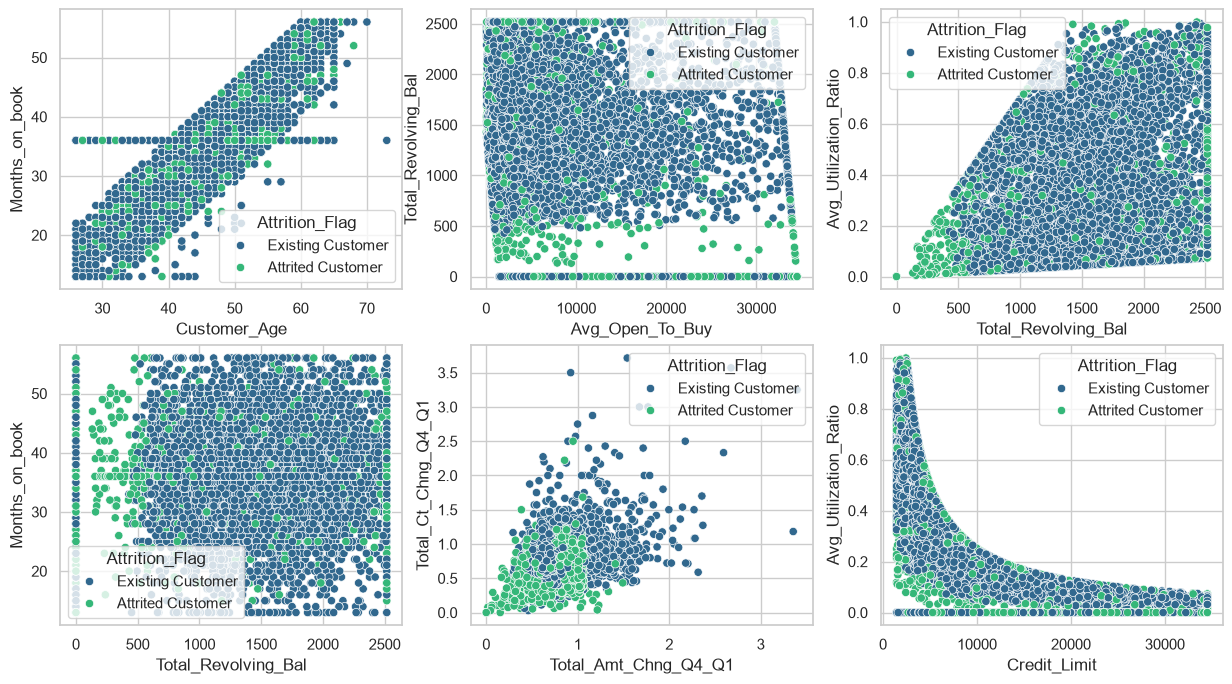

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.scatterplot(data=df, x='Customer_Age', y='Months_on_book', hue='Attrition_Flag', ax=axes[0][0], palette=palette)
sns.scatterplot(data=df, x='Avg_Open_To_Buy', y='Total_Revolving_Bal',  hue='Attrition_Flag', ax=axes[0][1] ,palette=palette)
sns.scatterplot(data=df, x='Total_Revolving_Bal', y='Avg_Utilization_Ratio',  hue='Attrition_Flag', ax=axes[0][2], palette=palette)
sns.scatterplot(data=df, x='Total_Revolving_Bal', y='Months_on_book',  hue='Attrition_Flag', ax=axes[1][0], palette=palette)
sns.scatterplot(data=df, x='Total_Amt_Chng_Q4_Q1', y='Total_Ct_Chng_Q4_Q1',  hue='Attrition_Flag', ax=axes[1][1], palette=palette)
sns.scatterplot(data=df, x='Credit_Limit', y='Avg_Utilization_Ratio',  hue='Attrition_Flag', ax=axes[1][2], palette=palette)

plt.show()

**Analysis**: Interestingly, credit limit and average utilization rate exhibit an exponential decreasing relationship! This indicates that as the credit limit increases, the average utilization rate decreases at an exponential rate. Therefore, customers with higher credit limits use their credit cards less frequently.

This dynamic suggests that there is a non-linear relationship between credit limit and card usage, with a steeper decrease in utilization rate as the credit limit increases. This could be a valuable insight for the bank to understand its customers’ spending patterns and adjust its credit management and customer retention strategies.



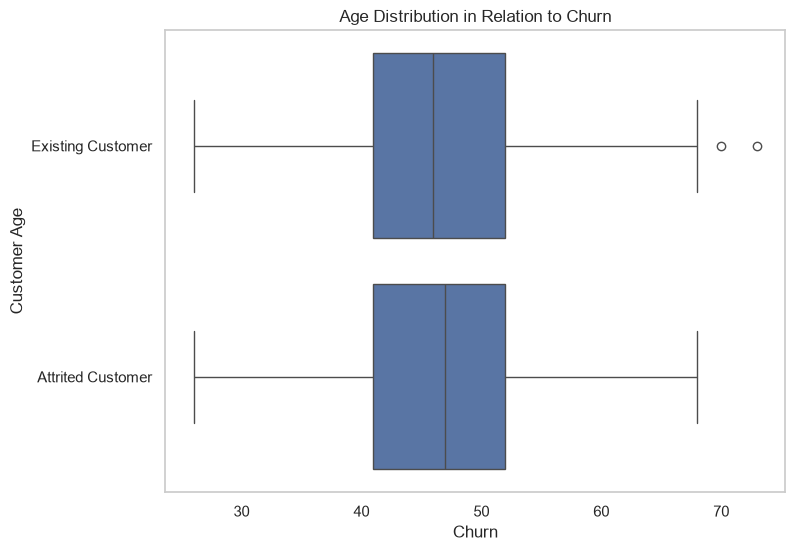

In [43]:
# Analysis of the Relationship between Age and Other Variables
# Boxplot of Customer Age in Relation to Churn
plt.figure(figsize=(8, 6))
sns.boxplot(x='Customer_Age', y='Attrition_Flag', data=df)
plt.title('Age Distribution in Relation to Churn')
plt.xlabel('Churn')
plt.ylabel('Customer Age')
plt.grid(False)
plt.show()

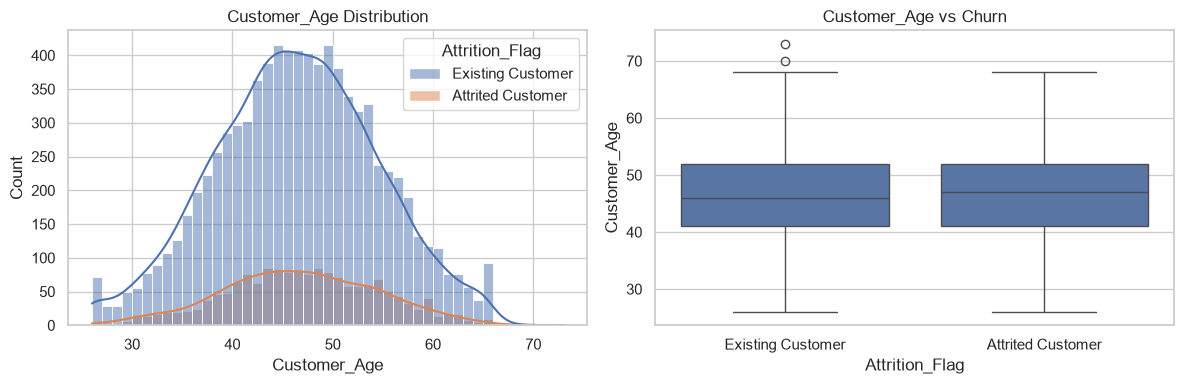

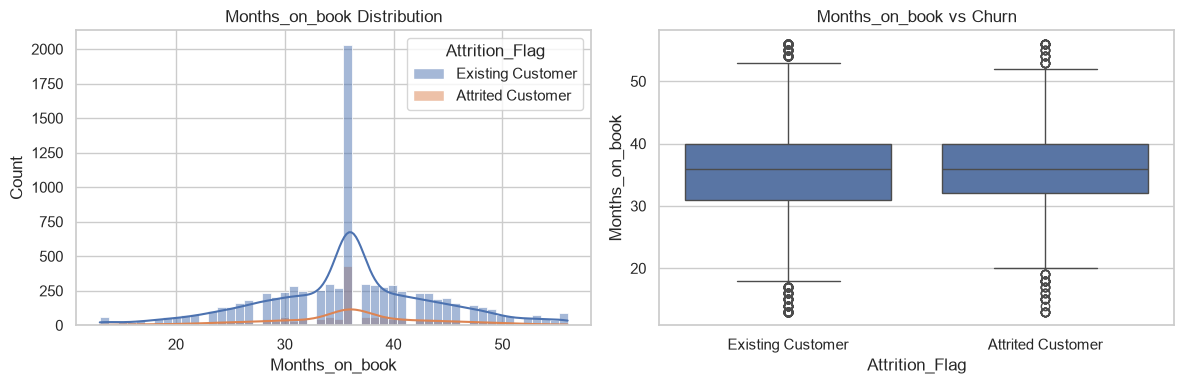

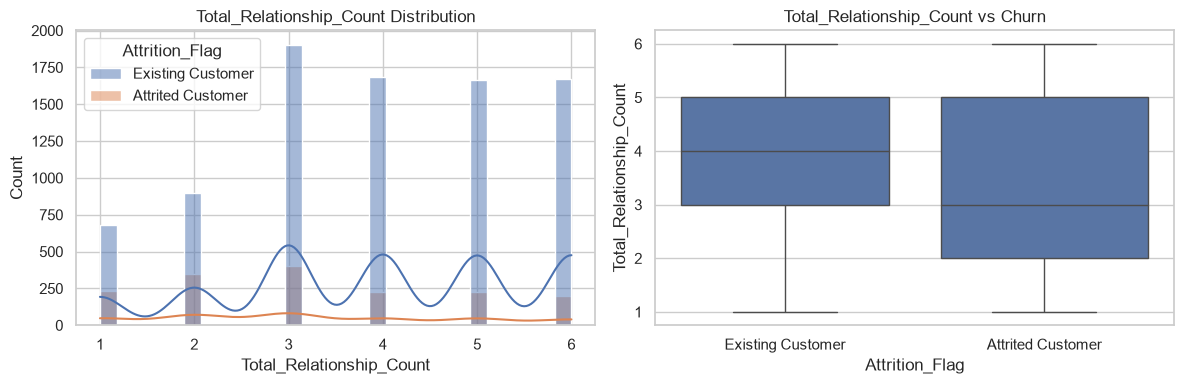

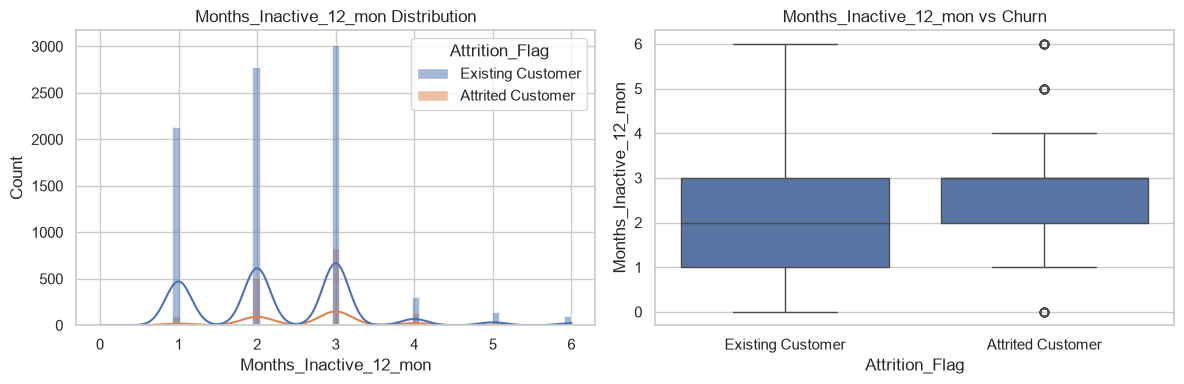

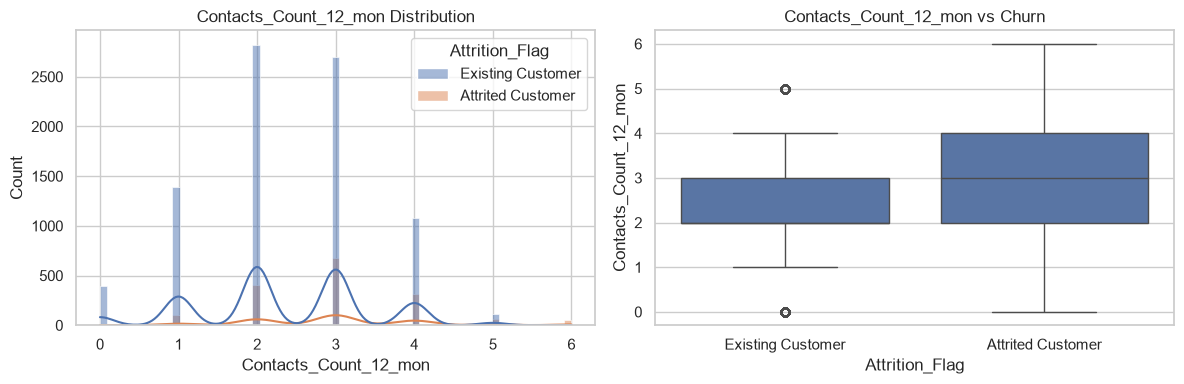

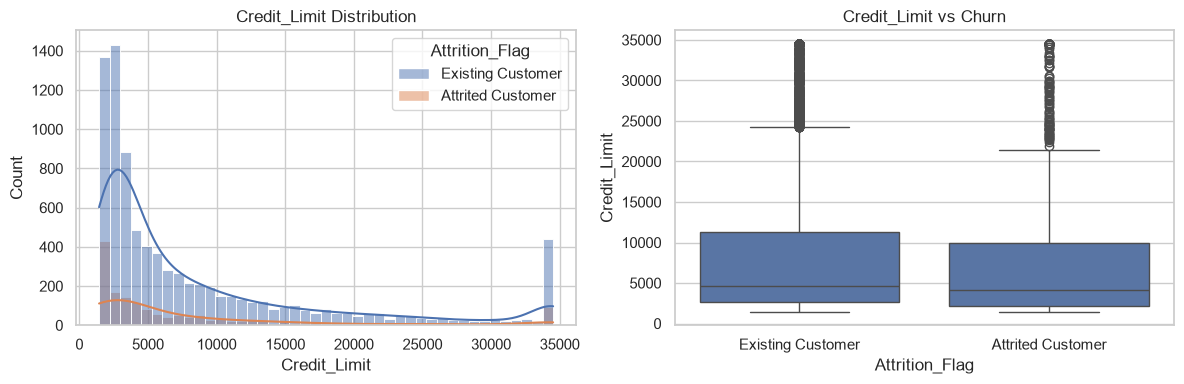

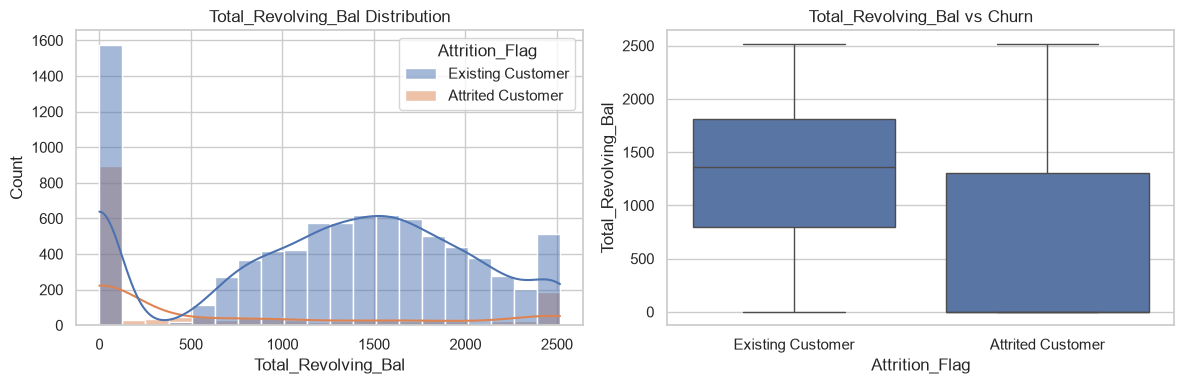

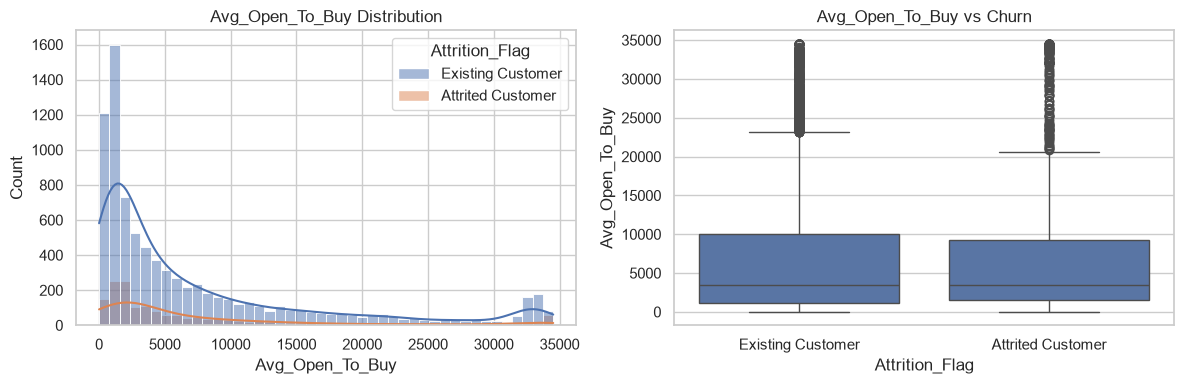

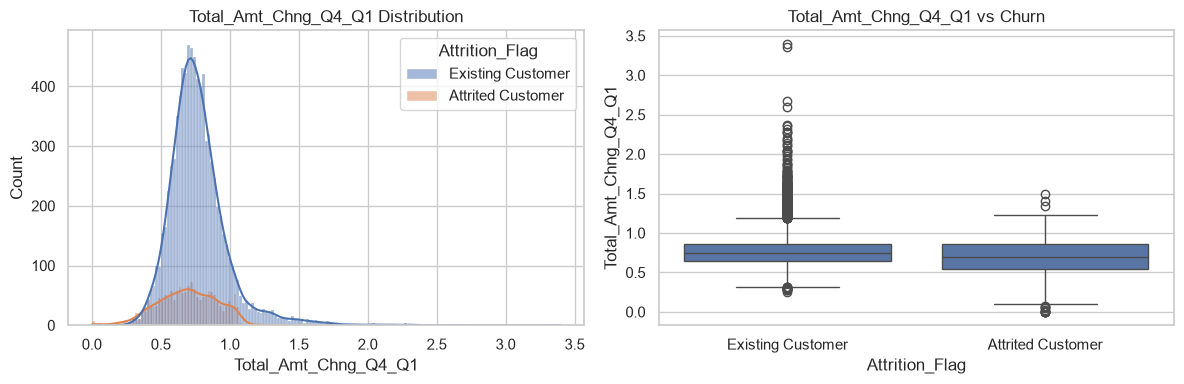

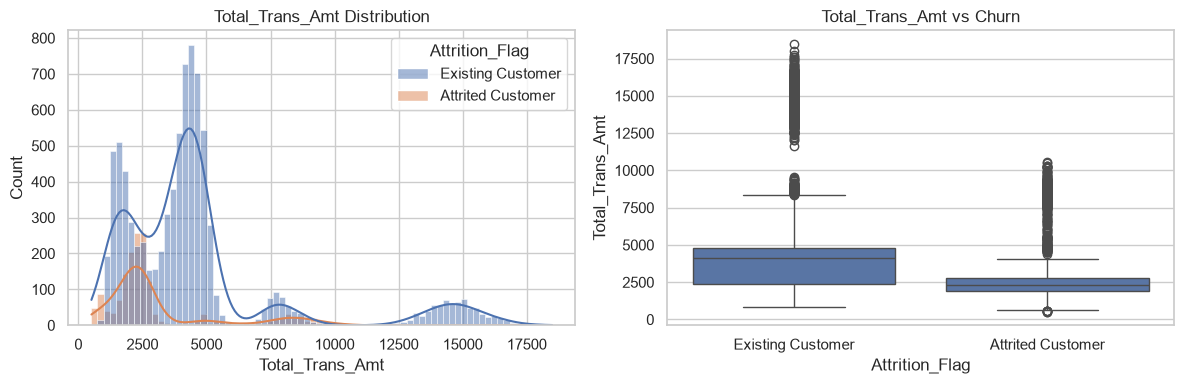

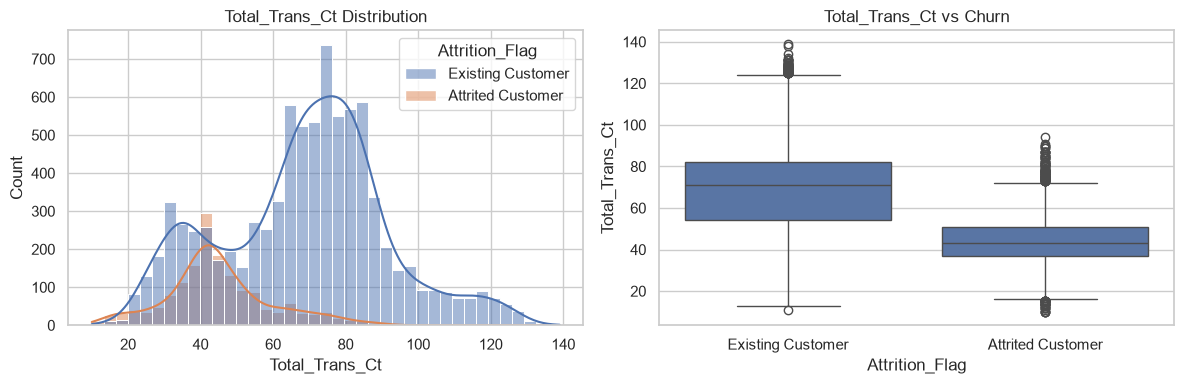

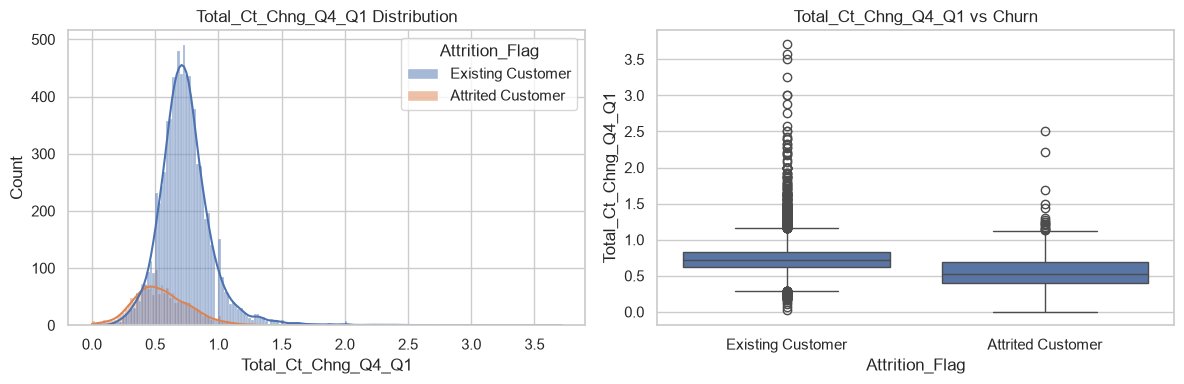

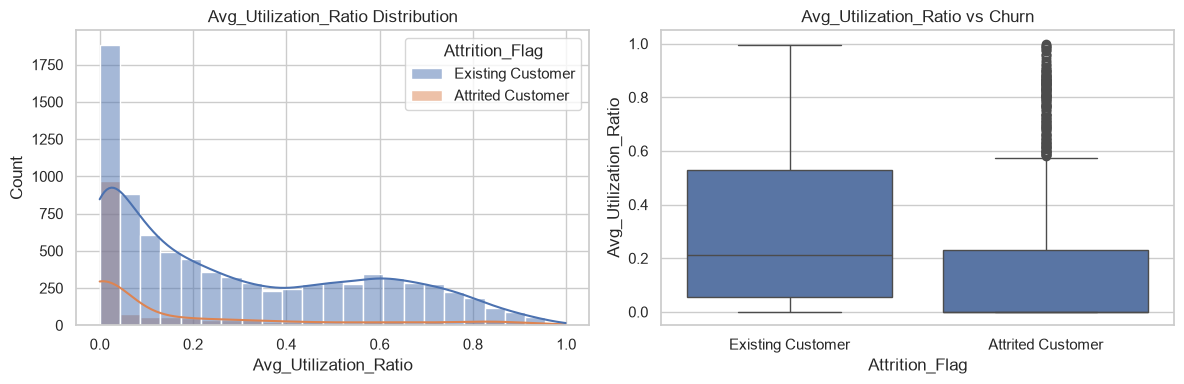

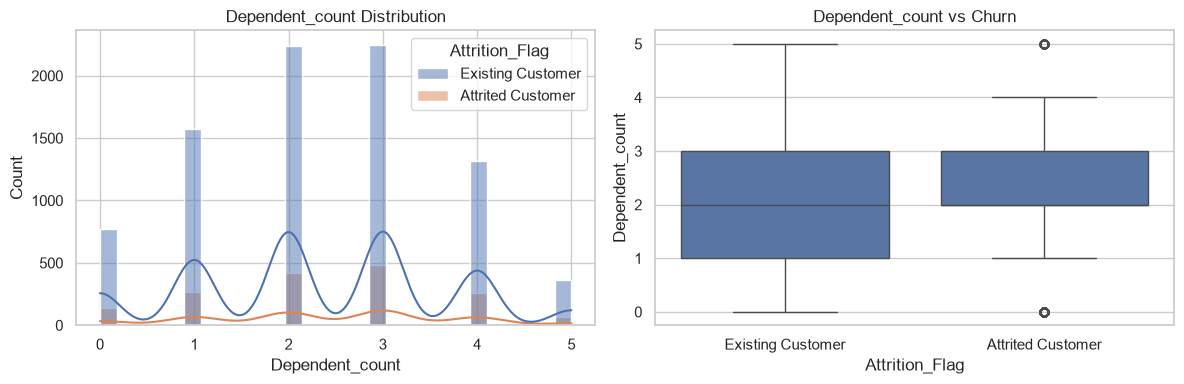

In [44]:
quant_cols = [
    'Customer_Age', 'Months_on_book', 'Total_Relationship_Count',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
    'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
    'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
    'Avg_Utilization_Ratio', 'Dependent_count'
]

for col in quant_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Distribution
    sns.histplot(
        data=df,
        x=col,
        hue='Attrition_Flag',
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title(f'{col} Distribution')

    # Boxplot
    sns.boxplot(
        data=df,
        x='Attrition_Flag',
        y=col,
        ax=axes[1]
    )
    axes[1].set_title(f'{col} vs Churn')

    plt.tight_layout()
    plt.show()

In [45]:
categorical_features = [c for c in df.columns if df[c].dtype == 'object' and c != 'Attrition_Flag']
numerical_features = [c for c in df.columns if df[c].dtype == 'number' and c != 'Attrition_Flag']
label = 'Attrition_Flag'

In [46]:
for col in categorical_features:

    churn_rate = (
        df.groupby(col)['Attrition_Flag']
        .apply(lambda x: (x == 'Attrited Customer').mean())
        .sort_values(ascending=False)
    )

    print(churn_rate)
    print("***********************************")

Gender
F    0.173572
M    0.146152
Name: Attrition_Flag, dtype: float64
***********************************
Education_Level
Doctorate        0.210643
Post-Graduate    0.178295
Unknown          0.168532
Uneducated       0.159381
Graduate         0.155691
College          0.152024
High School      0.152012
Name: Attrition_Flag, dtype: float64
***********************************
Marital_Status
Unknown     0.172230
Single      0.169414
Divorced    0.161765
Married     0.151269
Name: Attrition_Flag, dtype: float64
***********************************
Income_Category
$120K +           0.173315
Less than $40K    0.171862
Unknown           0.168165
$80K - $120K      0.157655
$40K - $60K       0.151397
$60K - $80K       0.134807
Name: Attrition_Flag, dtype: float64
***********************************
Card_Category
Platinum    0.250000
Gold        0.181034
Blue        0.160979
Silver      0.147748
Name: Attrition_Flag, dtype: float64
***********************************


### Data Cleaning 

In [47]:
# Check for null data in each column
df.isnull().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

### Data Preprocessing 

In [48]:
df = df.drop('CLIENTNUM', axis = 1)

In [49]:
# Create a mapping dictionary
mapping = {'Attrited Customer': 1, 
           'Existing Customer': 0}

# Apply mapping to convert column to numeric
df['Attrition_Flag'] = df['Attrition_Flag'].replace(mapping)

# Viewing dataset
df.head()


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


### Feature Engineering

Feature engineering is a crucial step in the data preparation process in data science and machine learning. It involves creating or transforming variables (also known as features) to improve the performance of machine learning models. Good feature engineering can increase model accuracy, reduce overfitting, and ultimately generate more meaningful insights from the data.

There are several feature engineering techniques, including creating new features from existing ones, normalizing data, handling missing values, and converting categorical variables to numeric variables, among others. Each technique is applied according to the nature of the data and the requirements of the problem at hand.-

**Label Encoder**

Label Encoder is a commonly used technique to convert categorical variables to numeric variables. In many datasets, it is common to find categorical variables that represent textual categories, such as “high,” “medium,” and “low,” or “yes” and “no.” However, most machine learning algorithms only accept numeric inputs. Therefore, it is necessary to convert these categorical variables into numbers before feeding them to the models.

The Label Encoder assigns a unique value to each category present in the categorical variable. For example, if we have a variable called "Size" with the categories "Small", "Medium" and "Large", the Label Encoder can assign the values ​​0, 1 and 2, respectively, to these categories. In this way, the categories are represented by integers, making them suitable for analysis by machine learning algorithms.

It is important to mention that the Label Encoder is more appropriate for ordinal categorical variables, that is, those in which there is an intrinsic order between the categories. For nominal categorical variables, where there is no such order, other techniques, such as One-Hot Encoding, may be more appropriate.

In summary, feature engineering, together with techniques such as the Label Encoder, plays a fundamental role in preparing data for analysis and modeling in data science and machine learning. These techniques allow data to be adequately processed by machine learning algorithms, contributing to the construction of more accurate and effective models.

In [50]:
# Importing library
from sklearn.preprocessing import LabelEncoder

# Creating the Label encoder
Label_pre = LabelEncoder()

# Data type transformation
data_cols=df.select_dtypes(exclude=['int','float']).columns
label_col =list(data_cols)

# Applying encoder
df[label_col]=df[label_col].apply(lambda col:Label_pre.fit_transform(col))

# Viewing
Label_pre

Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Holds the label for each class.","ndarray[object](4,)","['Blue','Gold','Platinum','Silver']"


In [51]:
# Viewing dataset
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,1,3,3,1,2,0,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,0,5,2,2,4,0,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,1,3,2,1,3,0,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,0,4,3,3,4,0,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,1,3,5,1,2,0,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [52]:
os.makedirs("../data/processed", exist_ok=True)

OUTPUT_PATH = "../data/processed/churn_processed.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"Processed dataset saved to: {OUTPUT_PATH}")
print("Shape:", df.shape)

Processed dataset saved to: ../data/processed/churn_processed.csv
Shape: (10127, 20)


### Training an testing 
Data Splitting and the “Churn” Variable

Another crucial step in data preparation is splitting the data into training and testing sets. This split allows us to evaluate the model’s performance on data not seen during training, helping to avoid overfitting and assess the model’s generalizability.

Typically, when splitting the data, the predictor variables (also known as features) are separated from the variable of interest, which is the one we want to predict. For example, in a scenario of predicting churn in a telecommunications company, the variable of interest could be “Churn,” indicating whether or not a customer canceled the service. In this case, the features would be other information related to customers, such as contract length, plan type, number of complaints, among others.

By splitting the data into training and testing, we ensure that the model is trained on one part of the data and evaluated on another independent part. This helps to estimate the actual performance of the model when applied to new data, which is essential for making informed decisions in the real world.



In [53]:
# Split the data into features (X) and target (y)
X = df.drop("Attrition_Flag", axis=1) # Drop the target column to get the features
y = df["Attrition_Flag"] # Set the target column

In [54]:
print(X.shape)
print(y.shape)

(10127, 19)
(10127,)


### model training and evaluation

**Model Training and Data Splitting**

A crucial step after data preparation is model training. This involves splitting the data into training and testing sets. This split allows us to evaluate the model’s performance on data not seen during training, helping to avoid overfitting and assess the model’s generalization ability. In practice, it is common to adopt a standard split, such as the popular 80% training and 20% testing ratio. This split ensures that the model is trained on a substantial amount of data, while still having a significant amount for evaluation. For example, when predicting churn in a telecommunications company, we would split the data into features (such as usage history, plan type, etc.) and the variable of interest, “Churn”. We would then apply the training and testing split, where 80% of the data would be used to train the model and the remaining 20% ​​to evaluate its performance.

This practice of splitting the data is essential to ensure that the model is robust and able to generalize to new data not seen during training.

In [55]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 ,stratify=y ,random_state=42)

In [56]:
print(X_train.shape, y_train.shape)

(8101, 19) (8101,)


### Machine Learning model 

Here, in the fifth stage of the project, I am focused on implementing machine learning models. I am developing eight different algorithms for analysis, which include Logistic Regression, Naive Bayes, Decision Tree, Random Forest, AdaBoost, Gradient Boosting, XGBoost, and LightGBM. This diversity of algorithms allows us to explore different approaches and techniques for the problem at hand. During the training process, we closely monitor the performance of each model, trying to identify the one that best fits the data and provides the most accurate predictions. This stage is crucial because it allows us to evaluate and compare the performance of each algorithm, thus selecting the most effective machine learning model for our specific application.

Throughout this stage, I am developing and training eight different machine learning algorithms. These algorithms have been carefully selected to cover a wide range of techniques and characteristics, aiming to capture the complexity and nuances of the data being reported.

-**Logistic Regression**: A linear model used to solve binary classification problems.

-**Naive Bayes**: A probabilistic model based on Bayes' theorem, suitable for classification problems with independent features.

-**Decision Tree**: A model that uses a tree structure to represent hierarchical decision rules.

-**Random Forest**: An ensemble learning technique that combines multiple decision trees to improve model accuracy and robustness.

-**AdaBoost**: Another ensemble learning algorithm that iteratively adjusts the weights of observations to focus on the most difficult cases.

-**Gradient Boosting**: An ensemble learning technique that builds decision trees sequentially, optimizing a specific loss criterion.

-**XGBoost**: An efficient implementation of gradient boosting, known for its speed and superior performance.

-**LightGBM**: Another implementation of gradient boosting, designed to train models quickly and in a memory-efficient manner.

-**Training and Evaluation**

Each of these algorithms is trained and tuned using machine learning best practices. After training, we evaluate the performance of each model on a validation set, using metrics appropriate to our problem, such as precision, recall, F1-score, among others.

-**Selection of the Best Model**

At the end of this process, we will compare the performance of all models and select the one that presents the best results according to our evaluation criteria. This choice will be based not only on the performance metric, but also on the interpretability of the model, its generalization capacity, and its suitability to the requirements of the problem at hand.

This meticulous and comprehensive approach will allow us to identify the most effective machine learning model to solve our specific problem, providing valuable insights and driving informed decision-making.

In [57]:
# Importing libraries
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier, plot_importance as plot_importance_xgb
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier, plot_importance as plot_importance_lgbm
import matplotlib.pyplot as plt

# Metrics and model evaluation
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, classification_report

In [58]:
# Dictionary of models
models = { 
    # Logistic Regression model
    "Logistic Regression": LogisticRegression(),
    
    # Naive Bayes model
    "Naive Bayes": GaussianNB(),
       
    # Decision Tree model
    "Decision Tree Classifier": DecisionTreeClassifier(),
    
    # Random Forest model
    "Random Forest": RandomForestClassifier(),
    
    # AdaBoost model
    "AdaBoost": AdaBoostClassifier(),
    
    # Gradient Boosting model
    "Gradient Boosting": GradientBoostingClassifier(),
    
    # XGBoost model
    "XGBoost": XGBClassifier(),
    
    # LightGBM model
    "LightGBM": LGBMClassifier()
}


In [61]:
# Model training with tqdm
mlflow.start_run(run_name='Original' , nested = True)
mlflow.set_tag('Dataset', 'Original')

for name, model in tqdm(models.items(), desc="Training models", total=len(models)):

    with mlflow.start_run(run_name=name, nested=True):

        mlflow.set_tag('Model', name)
        mlflow.log_params({k: str(v) for k, v in model.get_params().items()})

        # Train model
        model.fit(X_train, y_train)

        # Model score
        score = model.score(X_test, y_test)

        mlflow.log_metric('accuracy', score)
        mlflow_log_model(model, name)

        # Model prediction
        model_pred = model.predict(X_test)

        # Displaying model results
        print()
        tqdm.write(f"Model: {name} has Accuracy {score:.2%}")

mlflow.end_run()

Training models:  12%|█▎        | 1/8 [00:18<02:09, 18.53s/it]2026/09/16 12:51:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Model: Logistic Regression has Accuracy 86.57%


Training models:  25%|██▌       | 2/8 [00:31<01:32, 15.39s/it]2026/09/16 12:51:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Model: Naive Bayes has Accuracy 88.89%


Training models:  38%|███▊      | 3/8 [00:47<01:18, 15.70s/it]


Model: Decision Tree Classifier has Accuracy 93.98%


2026/09/16 12:51:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Training models:  50%|█████     | 4/8 [01:02<01:00, 15.18s/it]


Model: Random Forest has Accuracy 95.80%


2026/09/16 12:51:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Training models:  62%|██████▎   | 5/8 [01:15<00:44, 14.67s/it]


Model: AdaBoost has Accuracy 94.42%


2026/09/16 12:52:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Training models:  75%|███████▌  | 6/8 [01:29<00:28, 14.17s/it]


Model: Gradient Boosting has Accuracy 96.50%


2026/09/16 12:52:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Training models:  88%|████████▊ | 7/8 [01:38<00:12, 12.56s/it]


Model: XGBoost has Accuracy 97.24%
[LightGBM] [Info] Number of positive: 1302, number of negative: 6799
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002238 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2047
[LightGBM] [Info] Number of data points in the train set: 8101, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.160721 -> initscore=-1.652874
[LightGBM] [Info] Start training from score -1.652874


2026/09/16 12:52:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Training models: 100%|██████████| 8/8 [01:57<00:00, 14.67s/it]


Model: LightGBM has Accuracy 96.89%


In [65]:
mlflow.end_run()


Machine Learning Model: Logistic Regression





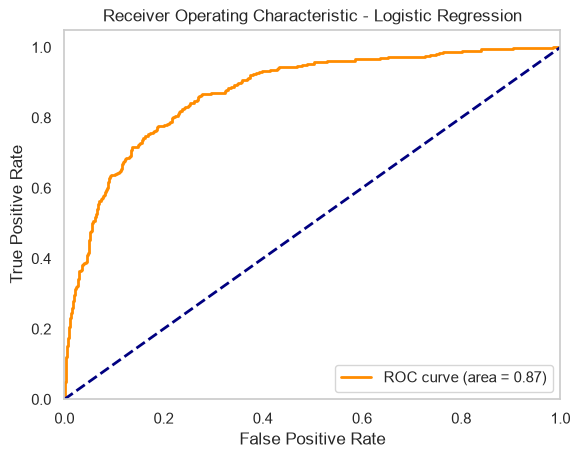



Accuracy: 0.8657453109575518




Confusion matrix 

 [[1619   82]
 [ 190  135]]

True Positives (TP) =  1619

True Negatives (TN) =  135

False Positives (FP) =  190

False Negatives (FN) =  82




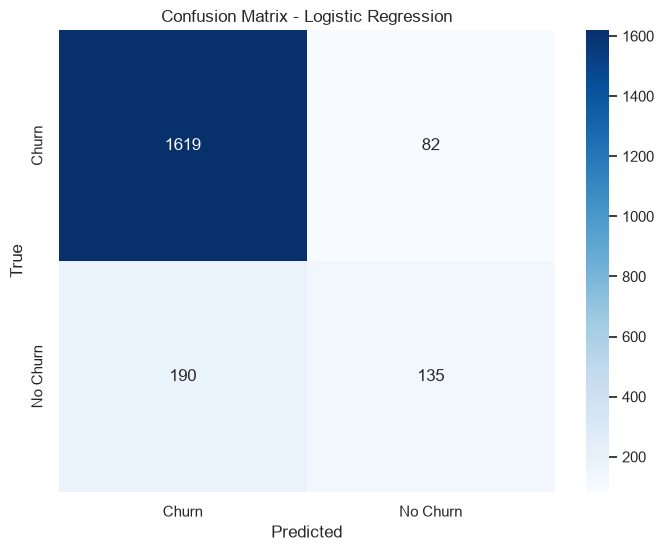



Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1701
           1       0.62      0.42      0.50       325

    accuracy                           0.87      2026
   macro avg       0.76      0.68      0.71      2026
weighted avg       0.85      0.87      0.85      2026


Machine Learning Model: Naive Bayes





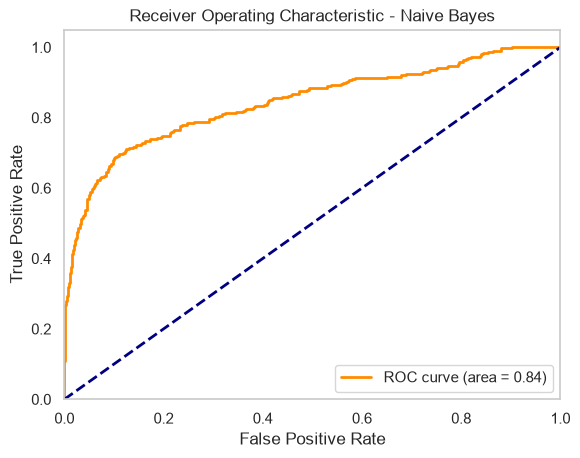



Accuracy: 0.8889437314906219




Confusion matrix 

 [[1616   85]
 [ 140  185]]

True Positives (TP) =  1616

True Negatives (TN) =  185

False Positives (FP) =  140

False Negatives (FN) =  85




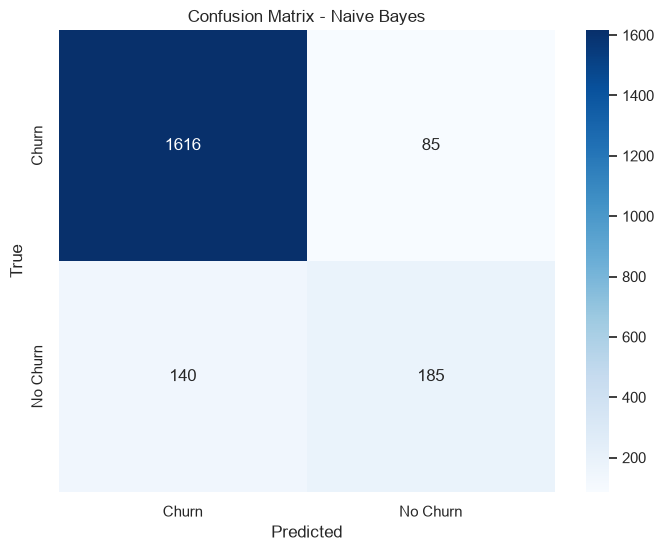



Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      1701
           1       0.69      0.57      0.62       325

    accuracy                           0.89      2026
   macro avg       0.80      0.76      0.78      2026
weighted avg       0.88      0.89      0.88      2026


Machine Learning Model: Decision Tree Classifier





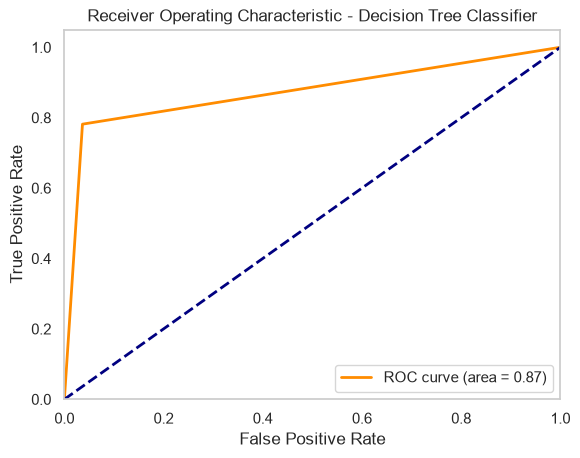



Accuracy: 0.9343534057255676




Confusion matrix 

 [[1639   62]
 [  71  254]]

True Positives (TP) =  1639

True Negatives (TN) =  254

False Positives (FP) =  71

False Negatives (FN) =  62




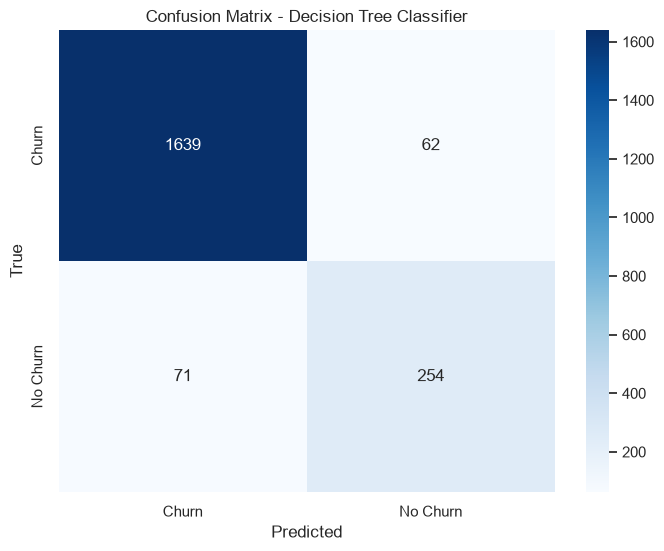



Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1701
           1       0.80      0.78      0.79       325

    accuracy                           0.93      2026
   macro avg       0.88      0.87      0.88      2026
weighted avg       0.93      0.93      0.93      2026


Machine Learning Model: Random Forest





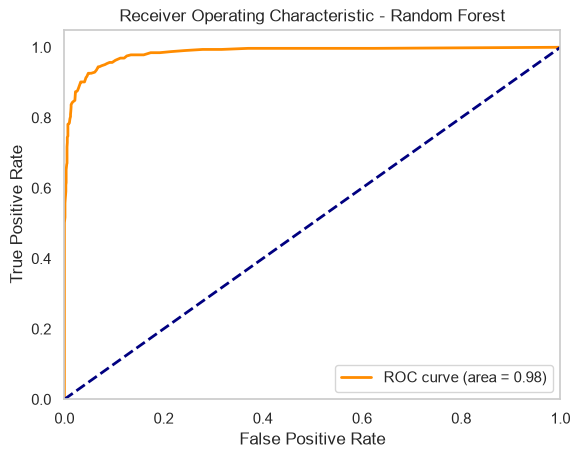



Accuracy: 0.9570582428430404




Confusion matrix 

 [[1684   17]
 [  70  255]]

True Positives (TP) =  1684

True Negatives (TN) =  255

False Positives (FP) =  70

False Negatives (FN) =  17




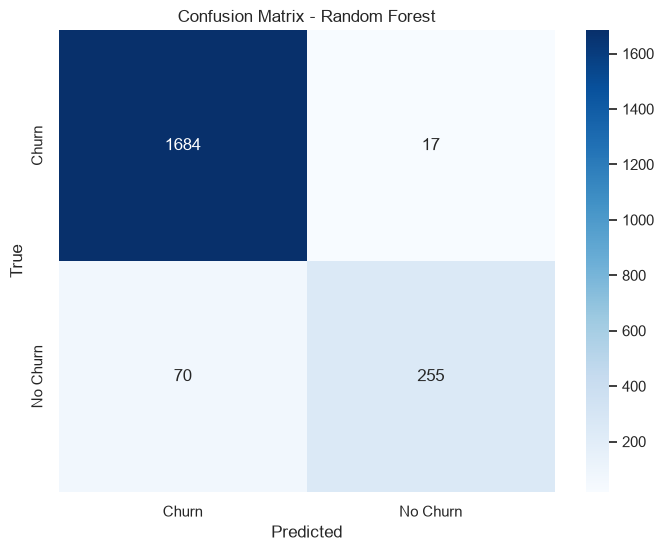



Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1701
           1       0.94      0.78      0.85       325

    accuracy                           0.96      2026
   macro avg       0.95      0.89      0.91      2026
weighted avg       0.96      0.96      0.96      2026


Machine Learning Model: AdaBoost





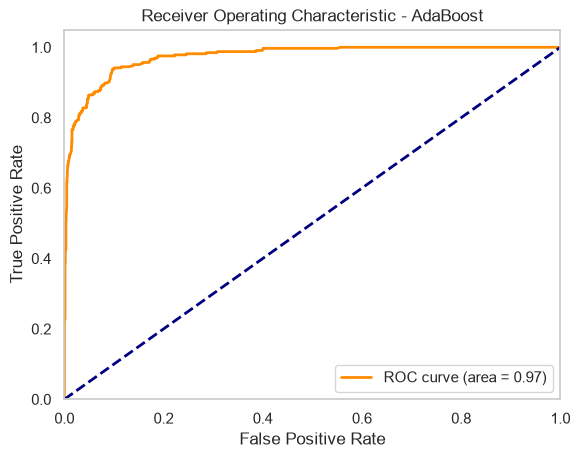



Accuracy: 0.9442250740375123




Confusion matrix 

 [[1676   25]
 [  88  237]]

True Positives (TP) =  1676

True Negatives (TN) =  237

False Positives (FP) =  88

False Negatives (FN) =  25




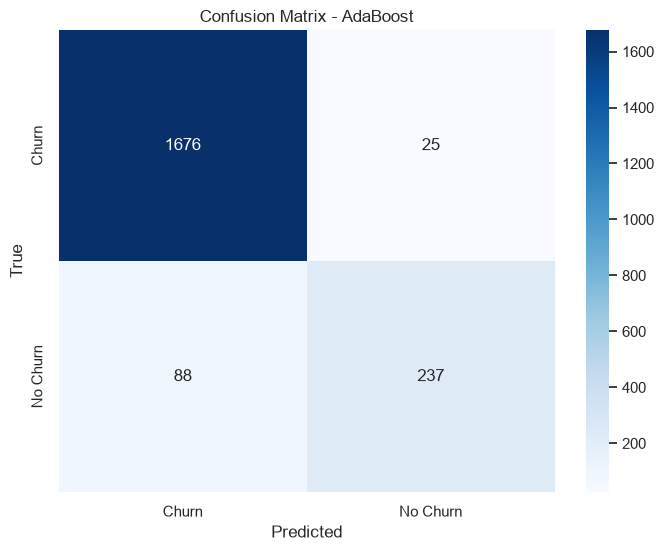



Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1701
           1       0.90      0.73      0.81       325

    accuracy                           0.94      2026
   macro avg       0.93      0.86      0.89      2026
weighted avg       0.94      0.94      0.94      2026


Machine Learning Model: Gradient Boosting





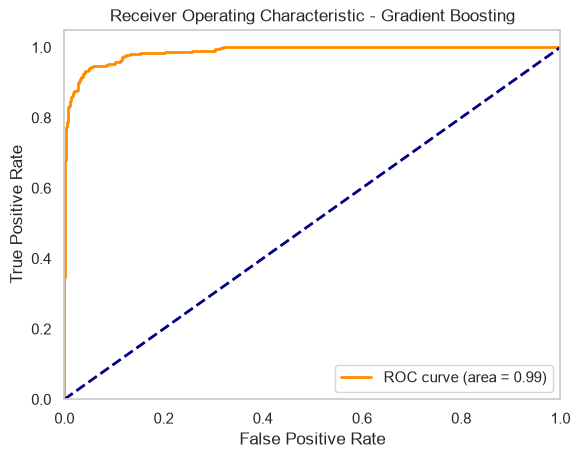



Accuracy: 0.9649555774925962




Confusion matrix 

 [[1689   12]
 [  59  266]]

True Positives (TP) =  1689

True Negatives (TN) =  266

False Positives (FP) =  59

False Negatives (FN) =  12




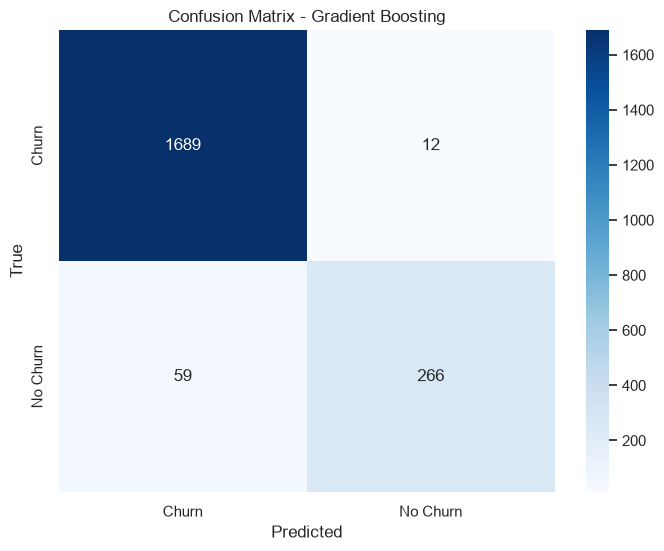



Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1701
           1       0.96      0.82      0.88       325

    accuracy                           0.96      2026
   macro avg       0.96      0.91      0.93      2026
weighted avg       0.96      0.96      0.96      2026


Machine Learning Model: XGBoost





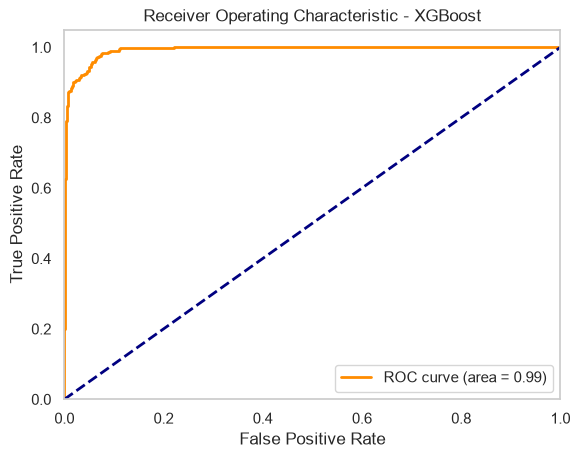



Accuracy: 0.9723593287265548




Confusion matrix 

 [[1687   14]
 [  42  283]]

True Positives (TP) =  1687

True Negatives (TN) =  283

False Positives (FP) =  42

False Negatives (FN) =  14




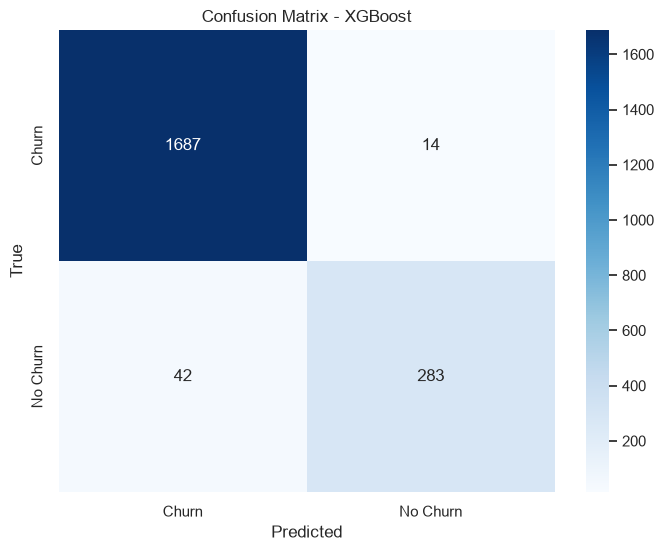



Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1701
           1       0.95      0.87      0.91       325

    accuracy                           0.97      2026
   macro avg       0.96      0.93      0.95      2026
weighted avg       0.97      0.97      0.97      2026

[LightGBM] [Info] Number of positive: 1302, number of negative: 6799
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003993 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2047
[LightGBM] [Info] Number of data points in the train set: 8101, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.160721 -> initscore=-1.652874
[LightGBM] [Info] Start training from score -1.652874

Machine Learning Model: LightGBM





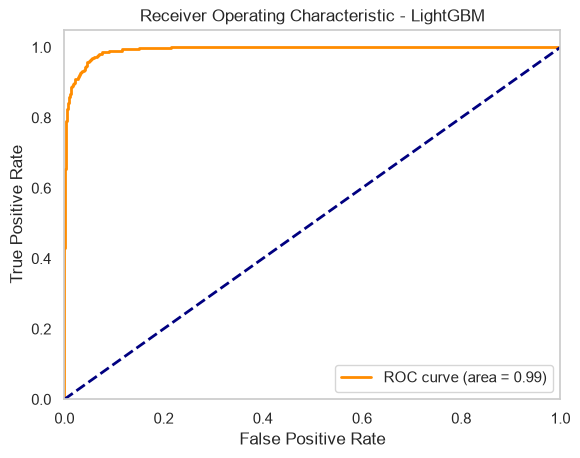



Accuracy: 0.9689042448173741




Confusion matrix 

 [[1681   20]
 [  43  282]]

True Positives (TP) =  1681

True Negatives (TN) =  282

False Positives (FP) =  43

False Negatives (FN) =  20




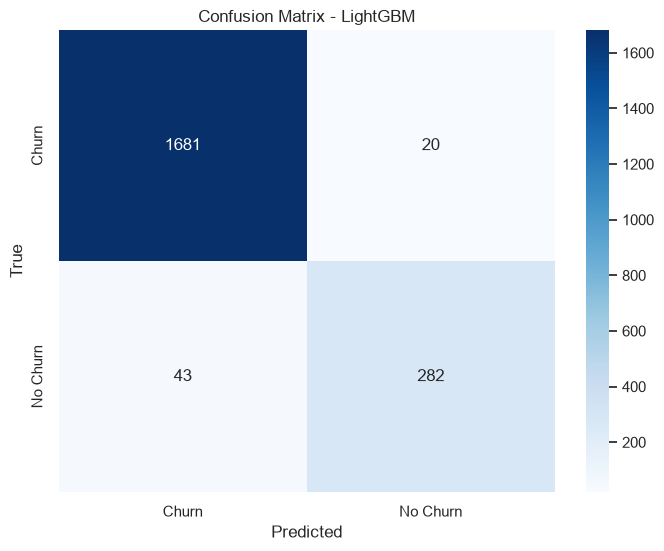



Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1701
           1       0.93      0.87      0.90       325

    accuracy                           0.97      2026
   macro avg       0.95      0.93      0.94      2026
weighted avg       0.97      0.97      0.97      2026



In [66]:
# Iterating over each model
for name, model in models.items():

    with mlflow.start_run(run_name=f"{name}_evaluation", nested=False):

        mlflow.set_tag('Model', name)
        mlflow.set_tag('Stage', 'evaluation')

        # Training the model
        model.fit(X_train, y_train)

        # Prediction on the test set
        y_pred = model.predict(X_test)

        print()
        print("Machine Learning Model:", name)

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
        roc_auc = auc(fpr, tpr)
        mlflow.log_metric('roc_auc', roc_auc)
        print()
        print()
        # Plotting the ROC Curve
        print()
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic - {}'.format(name))
        plt.legend(loc="lower right")
        plt.grid(False)
        mlflow.log_figure(plt.gcf(), f"roc_curve_{name}.png")
        plt.show()
        print()
        print()

        # Accuracy
        acc = accuracy_score(y_test, y_pred)
        mlflow.log_metric('accuracy', acc)
        print("Accuracy:", acc)
        print()
        print()
        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        print()
        print()
        print('Confusion matrix \n\n', cm)
        print('\nTrue Positives (TP) = ', cm[0,0])
        print('\nTrue Negatives (TN) = ', cm[1,1])
        print('\nFalse Positives (FP) = ', cm[1,0])
        print('\nFalse Negatives (FN) = ', cm[0,1])
        print()
        print()

        # Plotting the confusion matrix with Seaborn
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix - {}'.format(name))
        plt.xlabel('Predicted')
        plt.ylabel('True') 
        plt.xticks(ticks=[0.5, 1.5], labels=['Churn', 'No Churn'])
        plt.yticks(ticks=[0.5, 1.5], labels=['Churn', 'No Churn'])
        mlflow.log_figure(plt.gcf(), f"confusion_matrix_{name}.png")
        plt.show()
        print()
        print()

        # Classification Report
        report_txt = classification_report(y_test, y_pred)
        print("Classification Report:")
        print(report_txt)
        mlflow.log_text(report_txt, f"classification_report_{name}.txt")


**Model Evaluation and Best Model Selection: Exploring Metrics and Detailed Analysis**

**Model Evaluation**

In this crucial phase of the project, we proceed to the detailed evaluation of the previously trained machine learning models. Using performance metrics and analysis techniques, we seek to identify the most effective and robust model for solving our specific problem.

**Evaluation Metrics**

When evaluating the models, we consider a variety of performance metrics, which provide us with a comprehensive understanding of their effectiveness in different aspects. Among the most commonly used metrics are:

**Accuracy**: The proportion of correct predictions in relation to the total predictions made by the model.

**Precision**: The proportion of true positives (instances correctly classified as positive) in relation to the total instances classified as positive by the model.

**Recall**: The proportion of true positives in relation to the total positive instances present in the data.

**F1-Score**: The harmonic mean between precision and recall, providing a balanced measure between the two metrics.

**Support**: The number of actual occurrences of each class in the dataset.

**Confusion Matrix and Classification Report**

In addition to the metrics mentioned, we also explored the confusion matrix and classification report for a more detailed analysis of each model’s performance. The confusion matrix provides us with a visual view of the model’s predictions against the actual labels, while the classification report provides a more detailed description of the performance metrics for each class.

**Best Model Selection**

After a careful analysis of the evaluation metrics, we concluded that the Logistic Regression model demonstrated remarkable and consistent performance across all the metrics considered. With high accuracy, precision, recall, F1-Score, and satisfactory support, the Logistic Regression model stands out as the best fit for our specific problem.

**Conclusion and Next Steps**

With the selection of the best model, we are well positioned to extract valuable insights from the data and make informed decisions. However, this is just the first step in an ongoing process of improvement and refinement. In the next stages of the project, we will seek to further optimize the selected model, explore advanced hyperparameter tuning techniques, and consider additional strategies to improve the model’s performance and generalization in real-world environments.

### Feature Importance - Interpreting model results with SHAP values
**Feature Importance Analysis: Revealing the Most Relevant Factors**

**Feature Importance**

In this crucial step of the analysis, we explore the importance of features to understand which variables have the greatest impact on our model's prediction. Feature importance analysis provides valuable insights into which aspects of the data are most relevant to the model's decision-making.

**Identifying the Most Relevant Features**

By applying feature importance analysis, we can identify the features that have the greatest adherence and impact on the model's predictions. These features stand out for their ability to significantly influence the model's decisions, providing critical information about the main drivers of the phenomenon we are studying.

**Interpreting the Results**

By interpreting the results of feature importance analysis, we can identify important patterns and insights into the problem at hand. Through this analysis, we can discover which variables have the greatest influence on the variable of interest (e.g. "Churn" in a churn prediction problem) and how these variables are related to each other.

**Application of Insights**

The insights gained from feature importance analysis can guide strategic decisions in a variety of contexts. For example, these insights can be used to prioritize resource allocation, identify areas for improvement in business processes, or even to direct specific actions to mitigate identified risks.

**Conclusion**

Feature importance analysis is a fundamental step in understanding machine learning models and extracting valuable insights from data. By identifying the most relevant features, we can improve the interpretation and confidence in the models, as well as guide strategic actions based on solid and well-founded evidence.

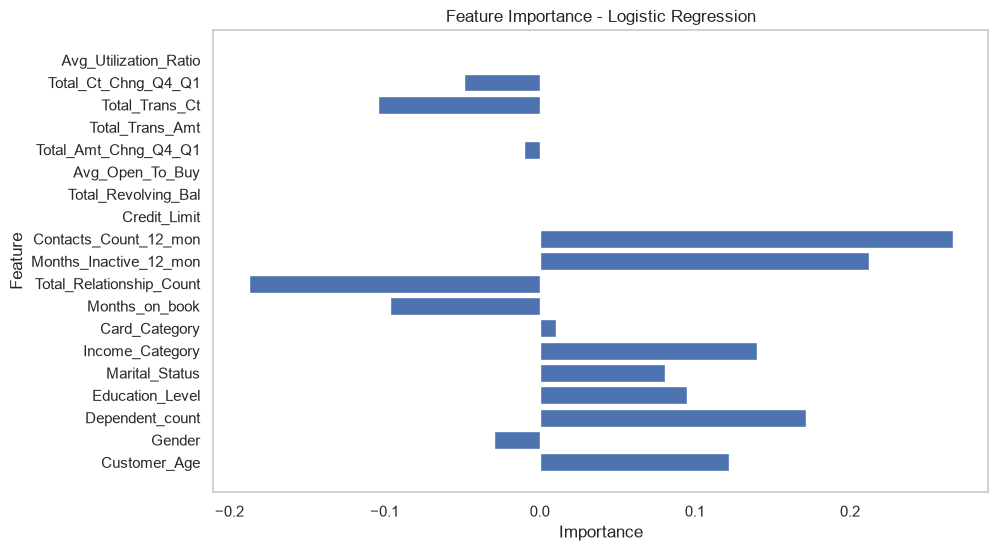

The model Naive Bayes does not support feature importance extraction.


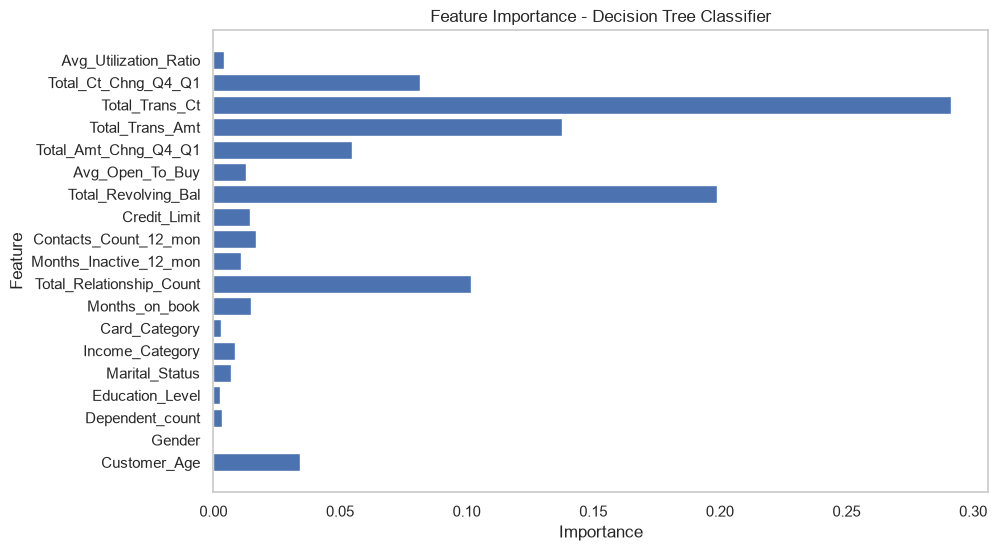

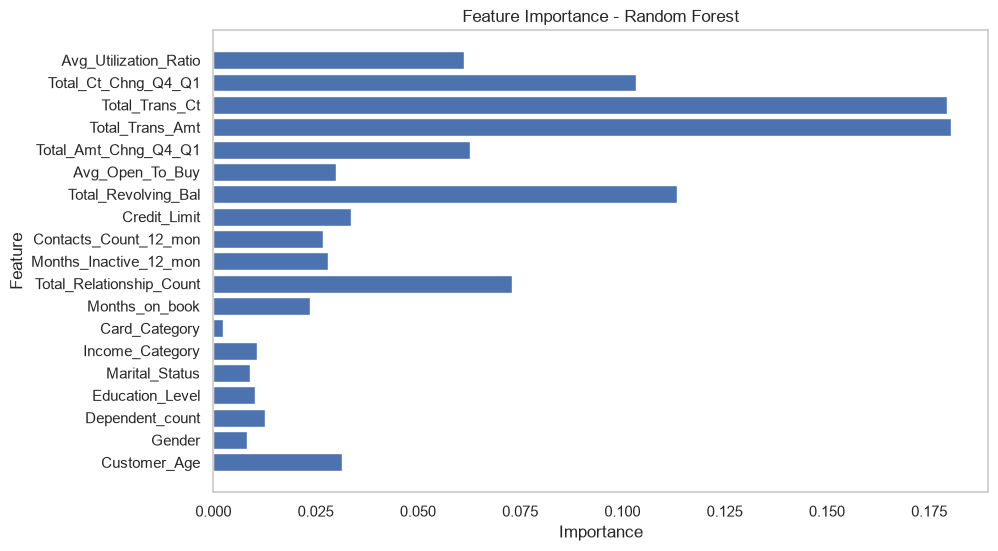

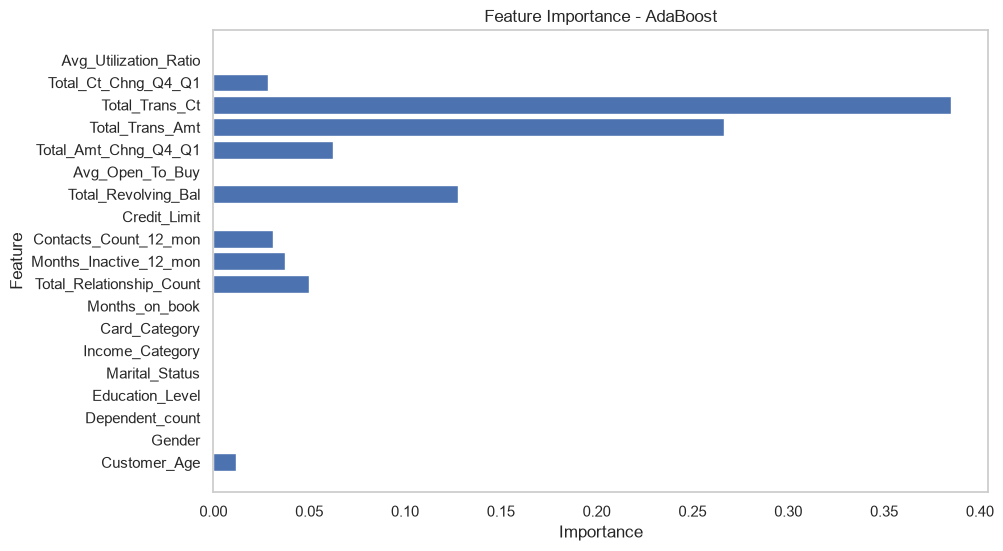

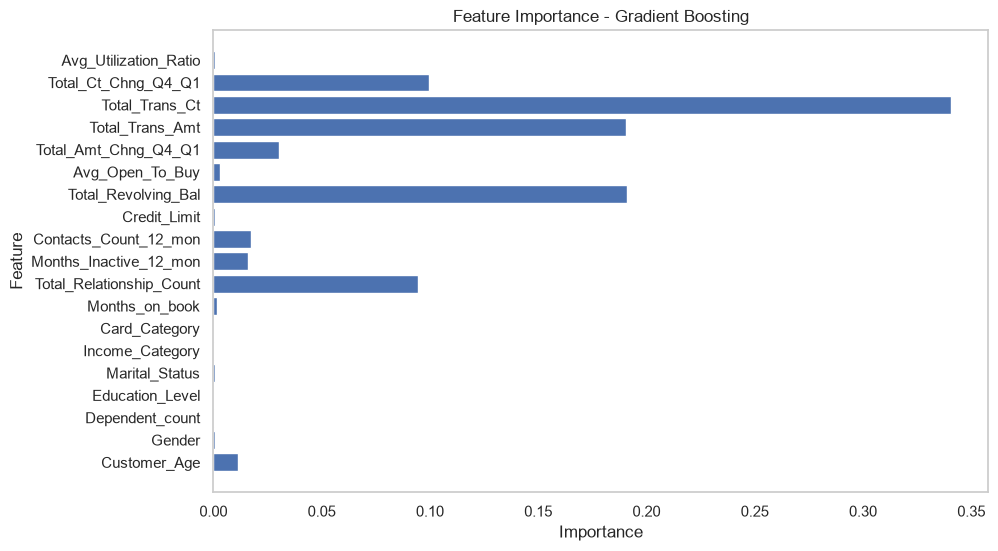

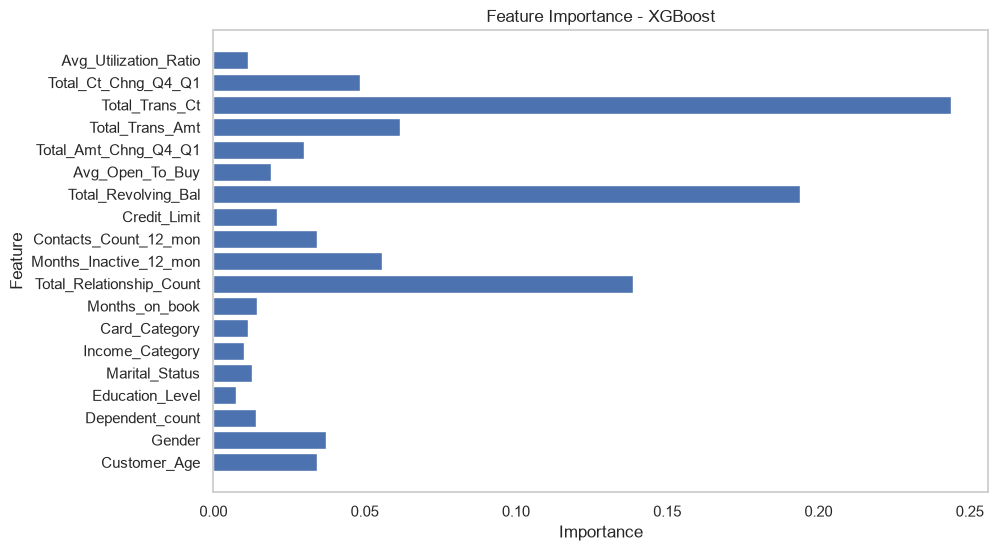

[LightGBM] [Info] Number of positive: 1302, number of negative: 6799
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002342 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2047
[LightGBM] [Info] Number of data points in the train set: 8101, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.160721 -> initscore=-1.652874
[LightGBM] [Info] Start training from score -1.652874


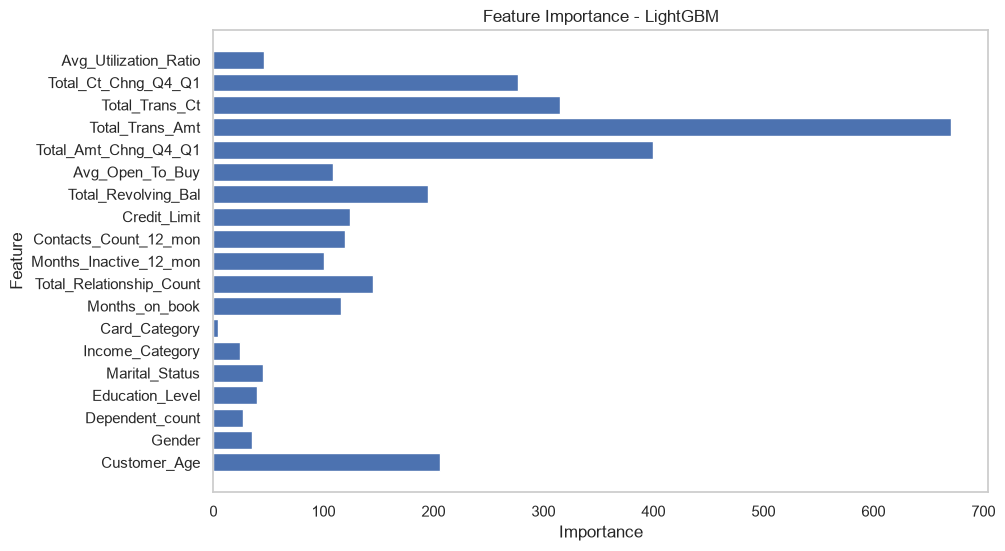

In [67]:
# Training the models and obtaining their feature importances
for model_name, model in models.items():

    with mlflow.start_run(run_name=f"{model_name}_feature_importance", nested=False):

        mlflow.set_tag('Model', model_name)
        mlflow.set_tag('Stage', 'feature_importance')

        model.fit(X_train, y_train)

        # Check if the model has 'feature_importances_' or 'coef_' attributes
        if hasattr(model, 'feature_importances_'):
            feature_importances = model.feature_importances_
        elif hasattr(model, 'coef_'):
            feature_importances = model.coef_[0]
        else:
            feature_importances = None

        # If feature importances are available, plot them
        if feature_importances is not None:
            # Plotting feature importances
            plt.figure(figsize=(10, 6))
            plt.barh(range(len(feature_importances)), feature_importances)
            plt.title(f"Feature Importance - {model_name}")
            plt.ylabel("Feature")
            plt.xlabel("Importance")
            plt.grid(False)
            plt.yticks(range(len(feature_importances)), X_train.columns)  # Assuming X_train is a pandas DataFrame
            mlflow.log_figure(plt.gcf(), f"feature_importance_{model_name}.png")
            plt.show()
        else:
            print(f"The model {model_name} does not support feature importance extraction.")


#### Model Analysis: Identifying the Model with the Greatest Adherence¶
In the analysis of the importance of the features carried out by the LightGBM model, a notable highlight falls on the variable "Total_Trans_Ct". This variable represents the total count of transactions made by a customer in a given period of time, be it monthly, quarterly or annually. In the context of financial services, especially in relation to credit cards, the number of transactions made is a fundamental metric for understanding customer behavior and engagement.

The importance attributed to the variable "Total_Trans_Ct" by the LGBM model suggests that it plays a crucial role in predicting and understanding customer behavior patterns in financial transactions. This metric is a direct reflection of a customer's financial activity and can provide valuable insights into their financial health, spending preferences and level of engagement with the services offered.

When considering the adherence of this variable to the LGBM model, we can infer that its inclusion contributes significantly to the accuracy of the predictions generated. However, it is important to note that feature importance analysis should not be limited to just one variable. Exploring other correlated features and their influence on the model can further enrich the understanding of customer behavior patterns and enhance the model’s ability to make accurate predictions.

Therefore, when assessing and interpreting feature importance in a model like LightGBM, it is essential to take a comprehensive and holistic approach, considering not only individual metrics but also the complex interactions between different variables. This will enable a more complete and informed analysis, resulting in more robust insights and better-informed decisions in the financial services context

### Model Results

In [68]:
# Dictionary to store the metrics

metrics_results = {'Model': [],
                   'Accuracy': [],
                   'Precision': [],
                   'Recall': [],
                   'F1-Score': [],
                   'Support': []}

# Iterating over each model
for name, model in models.items():

    with mlflow.start_run(run_name=f"{name}_metrics", nested=False):

        mlflow.set_tag('Model', name)
        mlflow.set_tag('Stage', 'metrics_summary')

        # Training the model
        model.fit(X_train, y_train)

        # Prediction on the test set
        y_pred = model.predict(X_test)
        # Calculating accuracy
        acc = accuracy_score(y_test, y_pred)

        # Calculating other metrics using classification_report
        report = classification_report(y_test, y_pred, output_dict=True)

        # Storing accuracy and other metrics in the dictionary
        metrics_results['Model'].append(name)
        metrics_results['Accuracy'].append(acc)
        metrics_results['Precision'].append(report['weighted avg']['precision'])
        metrics_results['Recall'].append(report['weighted avg']['recall'])
        metrics_results['F1-Score'].append(report['weighted avg']['f1-score'])
        metrics_results['Support'].append(report['weighted avg']['support'])

        mlflow.log_metrics({
            'accuracy': acc,
            'precision_weighted': report['weighted avg']['precision'],
            'recall_weighted': report['weighted avg']['recall'],
            'f1_weighted': report['weighted avg']['f1-score']
        })

# Creating a DataFrame with the results
df_metrics = pd.DataFrame(metrics_results)

# Displaying the DataFrame sorted by the accuracy column in descending order
df_metrics_sorted = df_metrics.sort_values(by='Accuracy', ascending=False)
print()
df_metrics_sorted


[LightGBM] [Info] Number of positive: 1302, number of negative: 6799
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000759 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2047
[LightGBM] [Info] Number of data points in the train set: 8101, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.160721 -> initscore=-1.652874
[LightGBM] [Info] Start training from score -1.652874



,Model,Accuracy,Precision,Recall,F1-Score,Support
6,XGBoost,0.972359,0.972044,0.972359,0.971850,2026.0
7,LightGBM,0.968904,0.968436,0.968904,0.968438,2026.0
5,Gradient Boosting,0.964956,0.964737,0.964956,0.963829,2026.0
3,Random Forest,0.959033,0.958525,0.959033,0.957591,2026.0
4,AdaBoost,0.944225,0.942809,0.944225,0.941739,2026.0
2,Decision Tree Classifier,0.931885,0.930953,0.931885,0.931365,2026.0
1,Naive Bayes,0.888944,0.882562,0.888944,0.884694,2026.0
0,Logistic Regression,0.865745,0.851201,0.865745,0.854435,2026.0


#### Machine Learning Model Results: Identifying Opportunities for Improvement
The results of the model evaluation are quite promising. The XGBoost model achieved an impressive accuracy of 97.23%, demonstrating its effectiveness in classifying data. Next, the LightGBM model performed remarkably well, with an accuracy of 96.89%. These numbers indicate that both models are capable of making predictions with high accuracy.

The high accuracy achieved by the XGBoost model suggests that it is ready to be deployed in a production environment. However, there are still opportunities for improvement, either by tuning hyperparameters to further improve performance or by developing more efficient pipelines for data preprocessing.

In addition, it is important to consider not only accuracy, but also other performance metrics, such as recall, precision, and F1-score, especially in cases where the dataset is imbalanced or requires a specific emphasis on certain types of errors.

Investing time in optimizing hyperparameters and building more robust pipelines can lead to additional gains in model performance and reliability. Additionally, it is crucial to continually monitor model performance after deployment, ensuring that it maintains its accuracy and relevance over time as new data is incorporated.

In summary, while the initial results are promising, there is room for improvement and refinement in both the LightGBM and XGBoost models. By taking an iterative approach focused on continuous improvement, we can ensure that our models deliver the best possible predictions and remain robust and reliable in dynamic and evolving environments.

In [70]:
# Importing libraries
from tqdm import tqdm
import pickle
import os

# Directory to save the models
MODELS_PATH = "../models"

# Create the folder if it doesn't exist
os.makedirs(MODELS_PATH, exist_ok=True)

# Dictionary of models
models = { 
            # Logistic Regression model
            "Logistic Regression": LogisticRegression(),
            
            # Naive Bayes model
            "Naive Bayes": GaussianNB(),
               
            # Decision Tree model
            "Decision Tree Classifier": DecisionTreeClassifier(),
            
            # Random Forest model
            "Random Forest": RandomForestClassifier(),

            # AdaBoost model
            "AdaBoost": AdaBoostClassifier(),
            
            # Gradient Boosting model
            "Gradient Boosting": GradientBoostingClassifier(),
            
            # XGBoost model
            "XGBoost": XGBClassifier(),
            
            # LightGBM model
            "LightGBM": LGBMClassifier()
}

# Model training with tqdm
for name, model in tqdm(models.items(), desc="Training models", total=len(models)):

    with mlflow.start_run(run_name=f"{name}_final", nested=False):

        mlflow.set_tag('Model', name)
        mlflow.set_tag('Stage', 'final_training')
        mlflow.log_params({k: str(v) for k, v in model.get_params().items()})

        # Train the model
        model.fit(X_train, y_train)

        # Model score
        score = model.score(X_test, y_test)
        mlflow.log_metric('accuracy', score)

        # Save the trained model with pickle
        model_path = os.path.join(MODELS_PATH, f"{name}_model.pkl")
        with open(model_path, 'wb') as file:
            pickle.dump(model, file)
        mlflow.log_artifact(model_path)
        mlflow_log_model(model, name)

        # Model prediction
        model_pred = model.predict(X_test)

        # Displaying model results
        print()
        tqdm.write(f"Model: {name} has an Accuracy of {score:.2%} and was saved as {model_path}")


Training models:  12%|█▎        | 1/8 [00:21<02:29, 21.36s/it]2026/09/16 12:59:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Model: Logistic Regression has an Accuracy of 86.57% and was saved as ../models\Logistic Regression_model.pkl


Training models:  25%|██▌       | 2/8 [00:36<01:46, 17.73s/it]2026/09/16 13:00:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Model: Naive Bayes has an Accuracy of 88.89% and was saved as ../models\Naive Bayes_model.pkl


Training models:  38%|███▊      | 3/8 [00:50<01:19, 15.84s/it]


Model: Decision Tree Classifier has an Accuracy of 93.34% and was saved as ../models\Decision Tree Classifier_model.pkl


2026/09/16 13:00:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Training models:  50%|█████     | 4/8 [01:03<00:59, 14.85s/it]


Model: Random Forest has an Accuracy of 95.85% and was saved as ../models\Random Forest_model.pkl


2026/09/16 13:00:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Training models:  62%|██████▎   | 5/8 [01:15<00:41, 13.67s/it]


Model: AdaBoost has an Accuracy of 94.42% and was saved as ../models\AdaBoost_model.pkl


2026/09/16 13:00:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Training models:  75%|███████▌  | 6/8 [01:28<00:26, 13.50s/it]


Model: Gradient Boosting has an Accuracy of 96.50% and was saved as ../models\Gradient Boosting_model.pkl


2026/09/16 13:00:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Training models:  88%|████████▊ | 7/8 [01:35<00:11, 11.34s/it]


Model: XGBoost has an Accuracy of 97.24% and was saved as ../models\XGBoost_model.pkl
[LightGBM] [Info] Number of positive: 1302, number of negative: 6799
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002015 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2047
[LightGBM] [Info] Number of data points in the train set: 8101, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.160721 -> initscore=-1.652874
[LightGBM] [Info] Start training from score -1.652874


2026/09/16 13:01:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Training models: 100%|██████████| 8/8 [01:46<00:00, 13.36s/it]


Model: LightGBM has an Accuracy of 96.89% and was saved as ../models\LightGBM_model.pkl


### Report

In [71]:
import os
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)


def create_report(path, models, X_test, y_test):

    results = []

    for name, model in models.items():

        # Predictions
        y_pred = model.predict(X_test)

        # Prediction probabilities
        y_prob = model.predict_proba(X_test)[:, 1]

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)

        # Assuming Class 1 = Churn
        tn, fp, fn, tp = cm.ravel()

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)

        roc_auc = roc_auc_score(
            y_test,
            y_prob
        )

        precision = precision_score(
            y_test,
            y_pred,
            pos_label=1
        )

        recall = recall_score(
            y_test,
            y_pred,
            pos_label=1
        )

        f1 = f1_score(
            y_test,
            y_pred,
            pos_label=1
        )

        # Matthews Correlation Coefficient
        mcc = matthews_corrcoef(
            y_test,
            y_pred
        )

        # Store results
        results.append({
            "Model": name,
            "Accuracy": accuracy,
            "ROC_AUC": roc_auc,
            "Precision_Churn": precision,
            "Recall_Churn": recall,
            "F1_Churn": f1,
            "MCC": mcc,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn
        })

        with mlflow.start_run(run_name=f"{name}_report", nested=False):
            mlflow.set_tag('Model', name)
            mlflow.set_tag('Stage', 'final_report')
            mlflow.log_metrics({
                'accuracy': accuracy,
                'roc_auc': roc_auc,
                'precision_churn': precision,
                'recall_churn': recall,
                'f1_churn': f1,
                'mcc': mcc
            })
            mlflow.log_metrics({
                'tp': float(tp),
                'tn': float(tn),
                'fp': float(fp),
                'fn': float(fn)
            })

    # Convert to DataFrame
    report_df = pd.DataFrame(results)

    # Sort by F1-score
    report_df = report_df.sort_values(
        by="F1_Churn",
        ascending=False
    )

    # Create directory if required
    os.makedirs(
        os.path.dirname(path),
        exist_ok=True
    )

    # Save CSV
    report_df.to_csv(
        path,
        index=False
    )

    print(f"Report saved successfully at: {path}")

    with mlflow.start_run(run_name="final_report_summary", nested=False):
        mlflow.set_tag('Stage', 'final_report_summary')
        mlflow.log_artifact(path)

    return report_df

report = create_report(
    "../outputs/metrics/model_report_without_smote.csv",
    models,
    X_test,
    y_test
)


Report saved successfully at: ../outputs/metrics/model_report_without_smote.csv


### Conclusion 
The conclusion of this project is extremely important, as it revealed valuable insights into churn, or customer turnover, in the context of credit card services. During the analysis of the data, we identified crucial insights that can indicate whether a customer is inclined to cancel their credit card or if they are interested in acquiring new benefits offered by the card. This project covered several essential steps, from the initial analysis of the data to the implementation and evaluation of machine learning models. Key areas include data preprocessing to ensure quality and consistency, feature engineering to extract relevant information, and the appropriate division between training and testing sets to evaluate the performance of the models. In addition, we trained several machine learning models, including algorithms such as Naive Bayes, Logistic Regression, LightGBM, XGBoost, among others. Within this set, the LightGBM model stood out with excellent performance, delivering results that exceeded expectations. The confusion matrix analysis revealed that the XGBoost model achieved 1687 True Positives, 282 True Negatives, 42 False Positives, and 14 False Negatives.

However, it is worth noting that the success of this project is not limited to the performance of the final model. Each step of the process, from data cleaning to model optimization, contributed to a deeper understanding of the churn phenomenon and customer behavior patterns. Looking ahead, there are opportunities to expand this project by exploring other modeling techniques, such as neural networks, and incorporating additional data to further enrich the predictions. Furthermore, implementing customer retention strategies based on the insights generated can help mitigate churn and promote customer loyalty. In summary, this project demonstrated the power of data analytics and predictive modeling in identifying and understanding churn in credit card services. With a comprehensive, insight-driven approach, we can make more informed and strategic decisions to improve the customer experience and drive business success.